# Importações 

In [4]:
# Bibliotecas padrão
import os
import gc
import json
import shutil
import zipfile
import os

# Bibliotecas de terceiros
import ee
import geemap
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, silhouette_samples
from sklearn.mixture import GaussianMixture
from shapely.geometry import box
from sklearn.cluster import KMeans
from io import BytesIO
from glob import glob
from IPython.display import display_html
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
from dotenv import load_dotenv

print("Bibliotecas carregadas")

Bibliotecas carregadas


In [5]:
load_dotenv(encoding="utf-8")

True

In [6]:
# Roda o comando no terminal : earthengine authenticate --auth_mode=notebook
ee.Authenticate()
ee.Initialize(project="spatial-yew-490017-r3")
print(ee.String("Hello from the Earth Engine servers!").getInfo())

Hello from the Earth Engine servers!


In [7]:
# mostrar todas as colunas
pd.set_option("display.max_columns", None)

# não quebrar a largura da tabela
pd.set_option("display.expand_frame_repr", False)

# opcional: aumentar a largura máxima exibida
pd.set_option("display.width", 1000)

pd.set_option("display.max_rows", None)  # sem limite

In [8]:
FILES_DIR = "files"
os.makedirs(FILES_DIR, exist_ok=True)

PRINTS_DIR = os.path.join(FILES_DIR, "prints")
os.makedirs(PRINTS_DIR, exist_ok=True)

In [9]:
METRIC_CRS = "EPSG:5880"  # SIRGAS 2000 / Brazil Polyconic

In [10]:
# Limites das UCs federais, via serviço WFS da INDE/ICMBio

ucs_dir = os.path.join(FILES_DIR, "limites_ucs")
os.makedirs(ucs_dir, exist_ok=True)

uc_typename = "ICMBio:limiteucsfederais_a"
uc_output_path = os.path.join(ucs_dir, "limites_ucs.geojson")

if os.path.exists(uc_output_path):
    print(f"Already downloaded: {uc_output_path}")
else:
    wfs_url = (
        "https://geoservicos.inde.gov.br/geoserver/ICMBio/ows"
        f"?service=WFS&version=2.0.0&request=GetFeature"
        f"&typeName={uc_typename}&outputFormat=application/json"
    )
    response = requests.get(wfs_url, timeout=180, verify=False)
    response.raise_for_status()
    with open(uc_output_path, "wb") as f:
        f.write(response.content)
    print(f"Saved: {uc_output_path}")

gdf_ucs = gpd.read_file(uc_output_path)

# Reprojetar para CRS métrico
# gdf_ucs = gdf_ucs.to_crs("EPSG:5880")
gdf_ucs["geometry"] = gdf_ucs.geometry.buffer(0)  # corrige geometrias inválidas

Already downloaded: files\limites_ucs\limites_ucs.geojson


# AAF (ICMBio)

### Importação

In [2]:
# AAF — download via ArcGIS FeatureServer (anos 2010-2026)

BASE_URL = "https://services3.arcgis.com/KYEMegXJrTiWSYWk/arcgis/rest/services"
PAGE_SIZE = 2000

aaf_urls_by_year = {}

# Padrão dinâmico — anos 2010 a 2022 seguem a mesma convenção de nome
for year in range(2010, 2023):
    aaf_urls_by_year[year] = (
        f"{BASE_URL}/db_geo_compartilhado_dmif_fogo_aaf_{year}/FeatureServer/0"
    )

# Exceções — nomes de serviço mudaram ano a ano a partir de 2023
aaf_urls_by_year[2023] = f"{BASE_URL}/AAF_2023_DGEO_ICMBIO_oficial/FeatureServer/0"
aaf_urls_by_year[2024] = f"{BASE_URL}/AAF_2024_DGEO_ICMBIO_oficial/FeatureServer/0"
aaf_urls_by_year[2025] = f"{BASE_URL}/AAF_2025_DGEO_oficial/FeatureServer/0"
aaf_urls_by_year[2026] = f"{BASE_URL}/AAF_2026/FeatureServer/0"

print("Total de anos mapeados:", len(aaf_urls_by_year))

Total de anos mapeados: 17


In [3]:
# Download com paginação, salvando um GeoJSON por ano

aaf_dir = os.path.join(FILES_DIR, "aaf")
os.makedirs(aaf_dir, exist_ok=True)

aaf_downloaded_files = {}

for year, base_url in aaf_urls_by_year.items():

    output_path = os.path.join(aaf_dir, f"aaf_{year}.geojson")

    if os.path.exists(output_path):
        aaf_downloaded_files[year] = output_path
        continue

    # Paginação — segue baixando enquanto o servidor retornar página cheia
    all_features = []
    offset = 0

    while True:
        query_url = (
            f"{base_url}/query?where=1%3D1&outFields=*&outSR=4326&f=geojson"
            f"&resultOffset={offset}&resultRecordCount={PAGE_SIZE}"
        )
        response = requests.get(query_url, timeout=120)
        response.raise_for_status()
        page_data = response.json()

        features = page_data.get("features", [])
        if not features:
            break

        all_features.extend(features)

        if len(features) < PAGE_SIZE:
            break

        offset += PAGE_SIZE

    # Salvar como GeoJSON válido
    final_geojson = {"type": "FeatureCollection", "features": all_features}

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(final_geojson, f)

    aaf_downloaded_files[year] = output_path
    print(f"[{year}] Salvo — {len(all_features)} registros")

print("\nAnos baixados:", list(aaf_downloaded_files.keys()))

NameError: name 'os' is not defined

In [ ]:
# Carregar todos os anos, checando consistência de colunas antes de concatenar

aaf_gdf_list = []
reference_columns = None

for year, path in aaf_downloaded_files.items():
    gdf_year = gpd.read_file(path)

    if reference_columns is None:
        reference_columns = set(gdf_year.columns)
    else:
        diff = set(gdf_year.columns).symmetric_difference(reference_columns)
        if diff:
            print(f"[{year}] Diferença de colunas em relação ao primeiro ano: {diff}")

    gdf_year["file_year"] = year
    aaf_gdf_list.append(gdf_year)

gdf_aaf = gpd.GeoDataFrame(pd.concat(aaf_gdf_list, ignore_index=True))
gdf_aaf_old = gpd.GeoDataFrame(pd.concat(aaf_gdf_list, ignore_index=True))


print("Shape:", gdf_aaf.shape)
print("Colunas:", gdf_aaf.columns.tolist())
print("Anos presentes:", sorted(gdf_aaf["file_year"].unique()))

[2024] Diferença de colunas em relação ao primeiro ano: {'mes_nome', 'FID', 'data_img', 'area_ent', 'area_uc', 'bioma', 'ngi', 'GlobalID', 'mes_num', 'gr_nome', 'pk_aaf', 'data', 'ct', 'categoria', 'ano', 'cr', 'local'}
[2025] Diferença de colunas em relação ao primeiro ano: {'classe', 'mes_nome', 'FID', 'data_img', 'area_ent', 'bioma', 'Shape__Len', 'tipo', 'GlobalID', 'categoria', 'cr', 'local', 'area_uc', 'ngi', 'acao', 'mes_num', 'pk_aaf', 'data', 'Shape__Are', 'ct', 'gr_nome', 'ano'}
[2026] Diferença de colunas em relação ao primeiro ano: {'classe', 'mes_nome', 'FID', 'data_img', 'area_ent', 'bioma', 'Shape__Len', 'tipo', 'GlobalID', 'GlobalID_2', 'categoria', 'cr', 'local', 'area_uc', 'ngi', 'acao', 'mes_num', 'pk_aaf', 'data', 'Shape__Are', 'ct', 'gr_nome', 'ano'}
Shape: (41780, 33)
Colunas: ['pk_aaf', 'cnuc', 'nome_uc', 'area_ha', 'data_img', 'classe', 'satelite', 'obs', 'juliano', 'Shape__Area', 'Shape__Length', 'geometry', 'file_year', 'FID', 'data', 'ano', 'mes_nome', 'mes_n

### Tratamento dos dados

In [12]:
# Normalização das colunas de data, sem criar coluna nova, só preenchendo/corrigindo
# as 7 colunas existentes a partir da fonte mais confiável disponível por registro
#
# Prioridade: data_img (mais granular, legado 2011-2023) > data em epoch ms
# (esquema novo 2024-2026) > juliano + file_year (fallback, cobre parte de 2011
# e outros anos esparsos). Quando nenhuma fonte existe (2010 inteiro e parte de
# 2021), as colunas ficam nulas, não tem como reconstruir data que nunca existiu

month_abbreviations = {
    1: "jan", 2: "fev", 3: "mar", 4: "abr", 5: "mai", 6: "jun",
    7: "jul", 8: "ago", 9: "set", 10: "out", 11: "nov", 12: "dez",
}

date_from_img = pd.to_datetime(gdf_aaf["data_img"], errors="coerce")
date_from_epoch = pd.to_datetime(gdf_aaf["data"], unit="ms", errors="coerce")

julian_numeric = pd.to_numeric(gdf_aaf["juliano"], errors="coerce")
julian_numeric = julian_numeric.where(julian_numeric.between(1, 366))
date_from_julian = (
    pd.to_datetime(gdf_aaf["file_year"].astype(str), format="%Y", errors="coerce")
    + pd.to_timedelta(julian_numeric - 1, unit="D")
)

canonical_date = date_from_img.combine_first(date_from_epoch).combine_first(date_from_julian)

gdf_aaf["data_img"] = canonical_date
gdf_aaf["data"] = canonical_date.dt.date
gdf_aaf["ano"] = canonical_date.dt.year
gdf_aaf["mes_num"] = canonical_date.dt.month
gdf_aaf["mes_nome"] = gdf_aaf["mes_num"].map(month_abbreviations)
gdf_aaf["juliano"] = canonical_date.dt.dayofyear

# Tipagem final, Int64 nullable porque ainda sobra NaN nos registros sem nenhuma fonte
gdf_aaf["juliano"] = gdf_aaf["juliano"].astype("Int64")
gdf_aaf["file_year"] = gdf_aaf["file_year"].astype("Int64")
gdf_aaf["ano"] = gdf_aaf["ano"].astype("Int64")
gdf_aaf["mes_num"] = gdf_aaf["mes_num"].astype("Int64")
gdf_aaf["mes_nome"] = gdf_aaf["mes_nome"].astype("string")

print(f"Registros sem nenhuma fonte de data (permanecem nulos): {canonical_date.isna().sum()}")

Registros sem nenhuma fonte de data (permanecem nulos): 585


In [13]:
#  Reprojeção e correção de geometria

gdf_aaf = gdf_aaf.to_crs(METRIC_CRS)
gdf_aaf["geometry"] = gdf_aaf.geometry.buffer(0)

n_invalid = (~gdf_aaf.is_valid).sum()
print(f"Geometrias inválidas após buffer(0): {n_invalid}")
gdf_aaf = gdf_aaf[gdf_aaf.is_valid].copy()

Geometrias inválidas após buffer(0): 2


In [14]:
# Área e perímetro recalculados direto da geometria
# Shape__Area original oscila entre grau² e m² sem padrão fixo por ano
# (confirmado em 2024/2025 vs o resto), não é confiável em nenhum caso

gdf_aaf["area_ha_original"] = gdf_aaf["area_ha"]
gdf_aaf["area_ha"] = gdf_aaf.geometry.area / 10000
gdf_aaf["shape_length"] = gdf_aaf.geometry.length

In [15]:
# Limpeza de string "None" tratada como categoria válida

categorical_columns = ["classe", "acao", "tipo", "categoria"]
for column in categorical_columns:
    gdf_aaf[column] = gdf_aaf[column].replace("None", np.nan)

In [16]:
# Harmonização do tipo de evento
# classe cobre 2020-2024, acao cobre 2025-2026, nenhuma cobre 2010-2019
# tipo e categoria são dimensões diferentes, não entram nessa fusão

harmonization_map = {
    "aceiro": "aceiro",
    "fogo natural": "natural",
    "raio": "natural",
    "gestao de ignicao natural": "natural",
    "incendio": "incendio",
    "indigena": "antropica",
    "gestao de ignicao antropica": "antropica",
    "queima por indigenas isolados": "antropica",
    "outros": "outros",
    "queima controlada": "queima controlada",
    "queima prescrita": "queima prescrita",
}

gdf_aaf["event_type"] = (
    gdf_aaf["classe"]
    .combine_first(gdf_aaf["acao"])
    .map(harmonization_map)
)
gdf_aaf["management_type"] = gdf_aaf["tipo"]
gdf_aaf["response_category"] = gdf_aaf["categoria"]

In [17]:
# Remoção de duplicata geométrica exata

n_before = len(gdf_aaf)
gdf_aaf = gdf_aaf[
    ~gdf_aaf.geometry.apply(lambda geom: geom.wkb).duplicated()
].copy()
print(f"Duplicatas geométricas removidas: {n_before - len(gdf_aaf)}")

Duplicatas geométricas removidas: 283


In [18]:
# Backfill administrativo via overlay espacial com as UCs
# cnuc, bioma e area_uc são a mesma grandeza nas duas fontes, entram por combine_first

gdf_aaf = gdf_aaf.reset_index(drop=True)
gdf_aaf["event_id"] = gdf_aaf.index

admin_columns = ["cnuc", "bioma", "area_uc"]
needs_backfill = gdf_aaf[admin_columns].isna().any(axis=1)

events_to_backfill = gdf_aaf.loc[needs_backfill, ["event_id", "geometry"]]
uc_columns = ["cnuc", "bioma_pred", "areahaalb", "categoria_"]

overlay_result = gpd.overlay(
    events_to_backfill, gdf_ucs[uc_columns + ["geometry"]], how="intersection"
)
overlay_result["intersection_area"] = overlay_result.geometry.area

best_match = (
    overlay_result
    .sort_values("intersection_area", ascending=False)
    .drop_duplicates(subset="event_id", keep="first")
    .set_index("event_id")
)

gdf_aaf["cnuc"] = gdf_aaf["cnuc"].combine_first(gdf_aaf["event_id"].map(best_match["cnuc"]))
gdf_aaf["bioma"] = gdf_aaf["bioma"].combine_first(gdf_aaf["event_id"].map(best_match["bioma_pred"]))
gdf_aaf["area_uc"] = gdf_aaf["area_uc"].combine_first(gdf_aaf["event_id"].map(best_match["areahaalb"]))


print(f"Eventos com backfill administrativo via overlay: {best_match['cnuc'].notna().sum()} de {needs_backfill.sum()}")

Eventos com backfill administrativo via overlay: 27357 de 28895


c:\Users\ANDERSONALVESCOELHO\miniconda3\envs\geo\Lib\site-packages\geopandas\tools\overlay.py:375: UserWarning: `keep_geom_type=True` in overlay resulted in 9 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


In [19]:
# Limpeza final de colunas

dead_columns = ["Shape__Are", "Shape__Len", "GlobalID_2", "Shape__Area", "Shape__Length", "event_id"]
gdf_aaf = gdf_aaf.drop(columns=[c for c in dead_columns if c in gdf_aaf.columns])

print("Shape final:", gdf_aaf.shape)
print("\nDistribuição de event_type:")
print(gdf_aaf["event_type"].value_counts(dropna=False))

Shape final: (41495, 33)

Distribuição de event_type:
event_type
incendio             17076
NaN                  16187
queima prescrita      5743
queima controlada     1697
antropica              371
natural                212
aceiro                 105
outros                 104
Name: count, dtype: int64


### análise e dados inconsistentes

In [20]:
# Comparação de shape e schema, colunas de data, antes vs depois da normalização

date_columns = ["data_img", "data", "ano", "mes_num", "mes_nome", "juliano"]

print(f"gdf_aaf_old (original): {gdf_aaf_old.shape}")
print(f"gdf_aaf (tratado): {gdf_aaf.shape}")

print("\n=== dtype antes vs depois ===")
for column in date_columns:
    dtype_old = gdf_aaf_old[column].dtype if column in gdf_aaf_old.columns else "não existe"
    dtype_new = gdf_aaf[column].dtype if column in gdf_aaf.columns else "não existe"
    print(f"{column:12s} | antes: {str(dtype_old):20s} | depois: {str(dtype_new)}")

gdf_aaf_old (original): (41780, 33)
gdf_aaf (tratado): (41495, 33)

=== dtype antes vs depois ===
data_img     | antes: object               | depois: datetime64[us]
data         | antes: float64              | depois: object
ano          | antes: float64              | depois: Int64
mes_num      | antes: str                  | depois: Int64
mes_nome     | antes: str                  | depois: string
juliano      | antes: object               | depois: Int64


In [21]:
# % vazio por ano, antes vs depois, coluna por coluna
# usa file_year como referência comum, já que é a única coluna estável nas duas versões

pct_null_before = (
    gdf_aaf_old.groupby("file_year")[date_columns]
    .apply(lambda df: df.isna().mean() * 100)
    .round(1)
)

pct_null_after = (
    gdf_aaf.groupby("file_year")[date_columns]
    .apply(lambda df: df.isna().mean() * 100)
    .round(1)
)

for column in date_columns:
    comparison = pd.DataFrame({
        "antes": pct_null_before[column],
        "depois": pct_null_after[column],
    })
    comparison["reducao"] = comparison["antes"] - comparison["depois"]

    print(f"\n=== {column} ===")
    print(comparison)


=== data_img ===
           antes  depois  reducao
file_year                        
2010       100.0   100.0      0.0
2011        95.9     0.1     95.8
2012         0.0     0.0      0.0
2013         0.0     0.0      0.0
2014         0.0     0.0      0.0
2015         0.0     0.0      0.0
2016         0.0     0.0      0.0
2017         0.0     0.0      0.0
2018        13.0    13.1     -0.1
2019         0.0     0.0      0.0
2020         0.0     0.0      0.0
2021         1.5     1.4      0.1
2022         0.0     0.0      0.0
2023         0.0     0.0      0.0
2024       100.0     0.0    100.0
2025       100.0     0.0    100.0
2026       100.0     0.0    100.0

=== data ===
           antes  depois  reducao
file_year                        
2010       100.0   100.0      0.0
2011       100.0     0.1     99.9
2012       100.0     0.0    100.0
2013       100.0     0.0    100.0
2014       100.0     0.0    100.0
2015       100.0     0.0    100.0
2016       100.0     0.0    100.0
2017       100.0

In [22]:
# Faixa de datas (min/max) resultante, antes vs depois
# antes, 'data_img' e 'data' têm formato/unidade misturados, parseia igual
# fizemos no diagnóstico original, pra comparação justa

data_img_before = pd.to_datetime(gdf_aaf_old["data_img"], errors="coerce")
data_epoch_before = pd.to_datetime(gdf_aaf_old["data"], unit="ms", errors="coerce")

print("=== Faixa de datas, ANTES ===")
print(f"data_img (parseada): {data_img_before.min()} até {data_img_before.max()}")
print(f"data (epoch ms, parseada): {data_epoch_before.min()} até {data_epoch_before.max()}")

print("\n=== Faixa de datas, DEPOIS ===")
print(f"data_img (canônica): {gdf_aaf['data_img'].min()} até {gdf_aaf['data_img'].max()}")
print(f"ano: {gdf_aaf['ano'].min()} até {gdf_aaf['ano'].max()}")

=== Faixa de datas, ANTES ===
data_img (parseada): 2011-07-10 00:00:00 até 2023-12-31 00:00:00
data (epoch ms, parseada): 2024-01-01 00:00:00 até 2026-10-18 00:00:00

=== Faixa de datas, DEPOIS ===
data_img (canônica): 2011-04-20 00:00:00 até 2026-10-18 00:00:00
ano: 2011 até 2026


In [23]:
# Amostra lado a lado, mesmos registros antes e depois, pra inspeção visual direta
# usa índice comum, já que gdf_aaf perdeu alguns registros (geometria inválida/nula)

common_indices = gdf_aaf.index.intersection(gdf_aaf_old.index)
sample_indices = (
    pd.Series(common_indices)
    .groupby(gdf_aaf_old.loc[common_indices, "file_year"])
    .apply(lambda s: s.sample(min(2, len(s)), random_state=42))
)
sample_indices = sample_indices.explode().tolist()

side_by_side = pd.concat(
    {
        "antes": gdf_aaf_old.loc[sample_indices, date_columns],
        "depois": gdf_aaf.loc[sample_indices, date_columns],
    },
    axis=1,
)

side_by_side

antes                                                    depois                                           
                  data_img          data     ano mes_num mes_nome juliano   data_img        data   ano mes_num mes_nome juliano
220                   None           NaN     NaN     NaN      NaN    None        NaT         NaT  <NA>    <NA>     <NA>    <NA>
42                    None           NaN     NaN     NaN      NaN    None        NaT         NaT  <NA>    <NA>     <NA>    <NA>
1387                   NaT           NaN     NaN     NaN      NaN     241 2011-07-10  2011-07-10  2011       7      jul     191
663                    NaT           NaN     NaN     NaN      NaN     159 2011-08-10  2011-08-10  2011       8      ago     222
2753   2012-12-03 00:00:00           NaN     NaN     NaN      NaN     338 2012-09-05  2012-09-05  2012       9      set     249
3104   2012-09-21 00:00:00           NaN     NaN     NaN      NaN     265 2012-09-17  2012-09-17  2012       9      set     261
3764   2013-08-24 00:00:00           NaN     NaN     NaN      NaN     236 2013-09-15  2013-09-15  2013       9      set     258
3985   2013-08-07 00:00:00           NaN     NaN     NaN      NaN     219 2013-06-21  2013-06-21  2013       6      jun     172
4881   2014-09-10 00:00:00           NaN     NaN     NaN      NaN     253 2014-07-17  2014-07-17  2014       7      jul     198
5783   2014-06-11 00:00:00           NaN     NaN     NaN      NaN     162 2014-08-28  2014-08-28  2014       8      ago     240
6444   2015-09-06 00:00:00           NaN     NaN     NaN      NaN     249 2015-09-27  2015-09-27  2015       9      set     270
7370   2015-07-05 00:00:00           NaN     NaN     NaN      NaN     186 2015-09-22  2015-09-22  2015       9      set     265
9973   2016-04-11 00:00:00           NaN     NaN     NaN      NaN   101.0 2017-10-18  2017-10-18  2017      10      out     291
9729   2016-08-23 00:00:00           NaN     NaN     NaN      NaN   236.0 2016-08-08  2016-08-08  2016       8      ago     221
11812  2017-09-18 00:00:00           NaN     NaN     NaN      NaN     261 2017-09-03  2017-09-03  2017       9      set     246
12247  2017-09-11 00:00:00           NaN     NaN     NaN      NaN     254 2017-07-24  2017-07-24  2017       7      jul     205
13721  2018-07-03 00:00:00           NaN     NaN     NaN      NaN     184 2018-08-27  2018-08-27  2018       8      ago     239
13338                  NaT           NaN     NaN     NaN      NaN       0        NaT         NaT  <NA>    <NA>     <NA>    <NA>
15367  2019-08-06 00:00:00           NaN     NaN     NaN      NaN     218 2019-09-20  2019-09-20  2019       9      set     263
14903  2019-05-10 00:00:00           NaN     NaN     NaN      NaN     130 2019-08-19  2019-08-19  2019       8      ago     231
18055  2020-07-22 00:00:00           NaN     NaN     NaN      NaN     203 2020-10-06  2020-10-06  2020      10      out     280
17942  2020-09-17 00:00:00           NaN     NaN     NaN      NaN     260 2020-07-06  2020-07-06  2020       7      jul     188
20016  2021-10-03 00:00:00           NaN     NaN     NaN      NaN   276.0 2021-10-07  2021-10-07  2021      10      out     280
19552  2021-07-11 00:00:00           NaN     NaN     NaN      NaN   192.0 2021-07-10  2021-07-10  2021       7      jul     191
22422  2022-10-08 00:00:00           NaN     NaN     NaN      NaN   259.0 2022-05-26  2022-05-26  2022       5      mai     146
21883  2022-09-16 00:00:00           NaN     NaN     NaN      NaN   244.0 2022-10-04  2022-10-04  2022      10      out     277
25670  2023-07-23 00:00:00           NaN     NaN     NaN      NaN     201 2023-08-02  2023-08-02  2023       8      ago     214
27352  2023-10-01 00:00:00           NaN     NaN     NaN      NaN     273 2023-10-16  2023-10-16  2023      10      out     289
31366                  NaN  1.724544e+12  2024.0      08      ago     238 2024-07-31  2024-07-31  2024       7      jul     213
32403                  NaN  1.725581e+12  2024.0     

In [24]:
# Registros removidos no bloco de reprojeção/correção de geometria
# comparação entre gdf_aaf_old (original) e gdf_aaf (já filtrado por is_valid)

removed_indices = gdf_aaf_old.index.difference(gdf_aaf.index)
print(f"Total de registros removidos: {len(removed_indices)}")
print(f"% do total original: {len(removed_indices) / len(gdf_aaf_old) * 100:.3f}%")

removed_records = gdf_aaf_old.loc[
    removed_indices, ["pk_aaf", "file_year", "nome_uc", "cnuc", "area_ha"]
].copy()

print("\n=== Distribuição por ano ===")
print(removed_records["file_year"].value_counts().sort_index())

Total de registros removidos: 285
% do total original: 0.682%

=== Distribuição por ano ===
file_year
2026    285
Name: count, dtype: int64


In [110]:
# Consolidado por ano, só nulo real, que é o que já sabemos que existe
# pra confirmar se a distribuição bate com o que já vimos nos diagnósticos anteriores
# (classe 2020-2024, acao/tipo 2025-2026, categoria 2024-2026)

null_by_year = pd.DataFrame({
    column: gdf_aaf_old.groupby("file_year")[column].apply(lambda s: s.isna().mean() * 100).round(1)
    for column in categorical_columns
})

null_by_year

,classe,acao,tipo,categoria
file_year,,,,
2010,100.0,100.0,100.0,100.0
2011,100.0,100.0,100.0,100.0
2012,100.0,100.0,100.0,100.0
2013,100.0,100.0,100.0,100.0
2014,99.8,100.0,100.0,100.0
2015,100.0,100.0,100.0,100.0
2016,100.0,100.0,100.0,100.0
2017,99.9,100.0,100.0,100.0
2018,100.0,100.0,100.0,100.0


In [26]:
# % de duplicata em relação ao volume total de cada ano, pra não confundir
# ano com muita duplicata absoluta com ano que simplesmente tem mais registro

is_duplicate = gdf_aaf_old.geometry.apply(lambda geom: geom.wkb if geom is not None else None).duplicated()

duplicates_by_year = gdf_aaf_old.loc[is_duplicate, "file_year"].value_counts().sort_index()
total_by_year = gdf_aaf_old["file_year"].value_counts().sort_index()

summary = pd.DataFrame({
    "duplicatas": duplicates_by_year,
    "total_registros": total_by_year,
}).fillna(0)
summary["duplicatas"] = summary["duplicatas"].astype(int)
summary["pct_duplicata"] = (summary["duplicatas"] / summary["total_registros"] * 100).round(2)
print(f"Total de duplicatas geométricas: {is_duplicate.sum()}")
summary

Total de duplicatas geométricas: 284


,duplicatas,total_registros,pct_duplicata
file_year,,,
2010,44,354,12.43
2011,18,1583,1.14
2012,17,1628,1.04
2013,0,953,0.00
2014,27,1397,1.93
2015,0,2088,0.00
2016,0,2025,0.00
2017,15,2692,0.56
2018,4,1513,0.26


In [27]:
# Quantidade e percentual de preenchimento por ano, colunas administrativas
# antes (gdf_aaf_old) e depois (gdf_aaf), lado a lado


admin_columns = ["cnuc", "nome_uc", "bioma", "ngi"]
existing_columns = [c for c in admin_columns if c in gdf_aaf.columns]
missing_columns = [c for c in admin_columns if c not in gdf_aaf.columns]

if missing_columns:
    print(f"Colunas que não existem mais em gdf_aaf: {missing_columns}")

counts_before = gdf_aaf_old.groupby("file_year")[admin_columns].apply(lambda df: df.notna().sum())
counts_after = gdf_aaf.groupby("file_year")[existing_columns].apply(lambda df: df.notna().sum())

pct_before = gdf_aaf_old.groupby("file_year")[admin_columns].apply(lambda df: (df.notna().mean() * 100).round(1))
pct_after = gdf_aaf.groupby("file_year")[existing_columns].apply(lambda df: (df.notna().mean() * 100).round(1))

html_count_before = counts_before.to_html().replace("<table", '<table style="display:inline-block; margin-right:40px"')
html_count_after = counts_after.to_html().replace("<table", '<table style="display:inline-block"')

html_pct_before = pct_before.to_html().replace("<table", '<table style="display:inline-block; margin-right:40px"')
html_pct_after = pct_after.to_html().replace("<table", '<table style="display:inline-block"')

display_html(
    f"<h4 style='display:inline-block; margin-right:250px'>Antes (quantidade)</h4><h4 style='display:inline-block'>Depois (quantidade)</h4>"
    f"<br>{html_count_before}{html_count_after}",
    raw=True,
)

display_html(
    f"<h4 style='display:inline-block; margin-right:280px'>Antes (%)</h4><h4 style='display:inline-block'>Depois (%)</h4>"
    f"<br>{html_pct_before}{html_pct_after}",
    raw=True,
)

,cnuc,nome_uc,bioma,ngi
file_year,,,,
2010,352,354,0,0
2011,1583,1583,0,0
2012,1628,1628,0,0
2013,953,953,0,0
2014,1381,1397,0,0
2015,2078,2088,0,0
2016,2010,2025,0,0
2017,2555,2692,0,0
2018,0,1513,0,0


,cnuc,nome_uc,bioma,ngi
file_year,,,,
2010,99.4,100.0,0.0,0.0
2011,100.0,100.0,0.0,0.0
2012,100.0,100.0,0.0,0.0
2013,100.0,100.0,0.0,0.0
2014,98.9,100.0,0.0,0.0
2015,99.5,100.0,0.0,0.0
2016,99.3,100.0,0.0,0.0
2017,94.9,100.0,0.0,0.0
2018,0.0,100.0,0.0,0.0


### Conexão com o banco AAF 

In [8]:
# Conexão com o banco Postgres via SQLAlchemy, credenciais via variável de ambiente


db_config = {
    "host": os.environ.get("PG_HOST", "localhost"),
    "port": os.environ.get("PG_PORT", "5432"),
    "database": os.environ.get("PG_DATABASE"),
    "user": os.environ.get("PG_USER"),
    "password": os.environ.get("PG_PASSWORD"),
}

connection_string = (
    f"postgresql+psycopg2://{db_config['user']}:{db_config['password']}"
    f"@{db_config['host']}:{db_config['port']}/{db_config['database']}"
)

engine = create_engine(connection_string)

# teste de conexão rápido
with engine.connect() as conn:
    result = conn.execute(text("SELECT version()"))
    print(result.fetchone())

('PostgreSQL 10.6 on x86_64-pc-linux-gnu, compiled by gcc (GCC) 4.8.5 20150623 (Red Hat 4.8.5-36), 64-bit',)


In [68]:
# Reconstrói schema_pivot usando udt_name, que traz o nome interno do tipo

query = """
SELECT table_name, column_name, udt_name AS data_type
FROM information_schema.columns
WHERE table_name ~ '^aaf_20(1[0-9]|2[0-6])$'
ORDER BY table_name, ordinal_position;
"""

with engine.connect() as conn:
    schema_all = pd.read_sql(text(query), conn)

schema_pivot = schema_all.pivot_table(
    index="table_name", columns="column_name", values="data_type", aggfunc="first"
)

schema_pivot = schema_pivot.reindex(sorted(schema_pivot.index, key=lambda x: int(x.split("_")[1])))

schema_pivot

column_name,acao,area_ha,classe,cnuc,data_img,geom,juliano,nome_uc,obs,pk_aaf,satelite,tipo
table_name,,,,,,,,,,,,
aaf_2010,NaN,float4,text,text,date,geometry,int4,text,text,int4,text,NaN
aaf_2011,NaN,float4,text,text,date,geometry,int4,text,text,int4,text,NaN
aaf_2012,NaN,float4,text,text,date,geometry,int4,text,text,int4,text,NaN
aaf_2013,NaN,float4,text,text,date,geometry,int4,text,text,int4,text,NaN
aaf_2014,NaN,float4,text,text,date,geometry,int4,text,text,int4,text,NaN
aaf_2015,NaN,float4,text,text,date,geometry,int4,text,text,int4,text,NaN
aaf_2016,NaN,float4,text,text,date,geometry,int4,text,text,int4,text,NaN
aaf_2017,NaN,float4,text,text,date,geometry,int4,text,text,int4,text,NaN
aaf_2018,NaN,float4,text,text,date,geometry,int4,text,text,int4,text,NaN


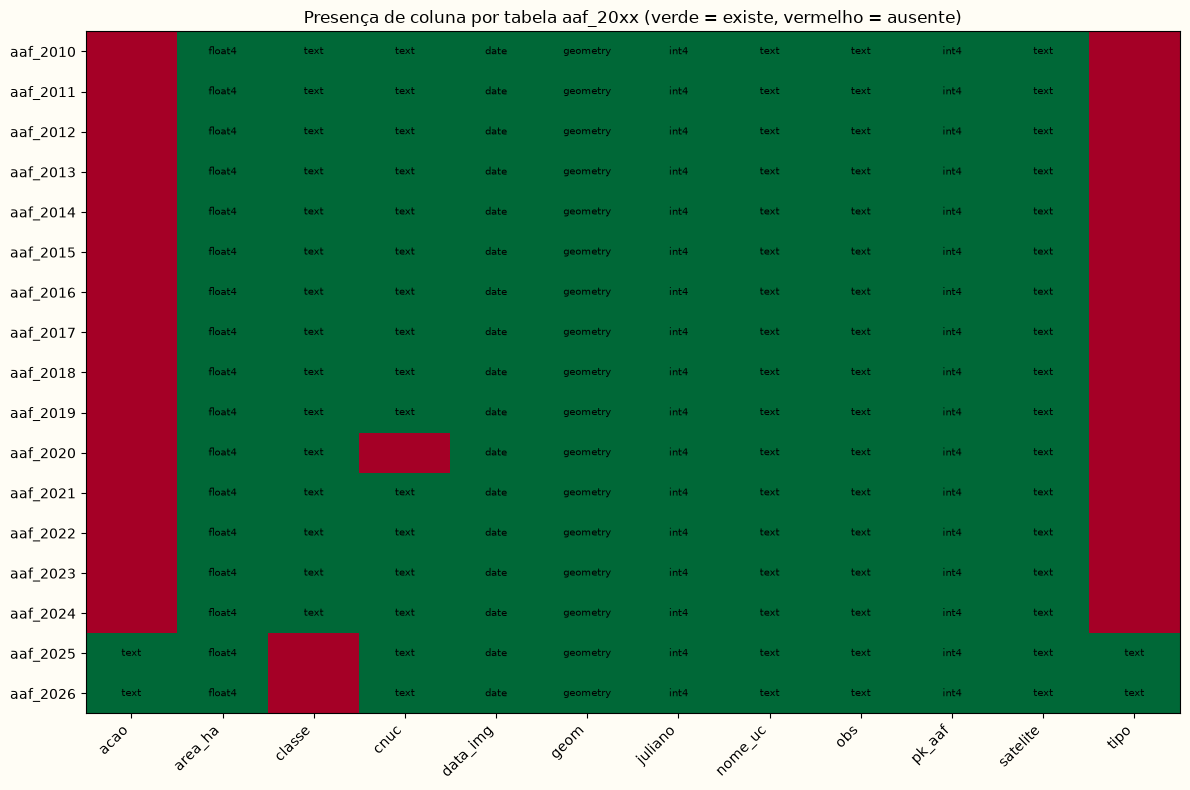

In [63]:
# Heatmap de presença/ausência de coluna, por tabela, com tipo completo anotado

fig, ax = plt.subplots(figsize=(12, 8), facecolor="#FFFDF5")

presence_matrix = schema_pivot.notna().astype(int)

im = ax.imshow(presence_matrix.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(presence_matrix.columns)))
ax.set_xticklabels(presence_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(presence_matrix.index)))
ax.set_yticklabels(presence_matrix.index)

# anota o tipo de dado completo dentro de cada célula, sem truncar
for i, table in enumerate(presence_matrix.index):
    for j, column in enumerate(presence_matrix.columns):
        value = schema_pivot.loc[table, column]
        text_label = value if isinstance(value, str) else ""
        ax.text(j, i, text_label, ha="center", va="center", fontsize=7)

ax.set_title("Presença de coluna por tabela aaf_20xx (verde = existe, vermelho = ausente)")
fig.tight_layout()
fig.savefig(os.path.join(PRINTS_DIR, "aaf_schema_presenca_por_tabela.png"), dpi=200)
plt.show()

In [69]:
# Monta o UNION ALL dinamicamente, agora com o schema dmif_fogo qualificado no FROM

target_columns = ["acao", "area_ha", "classe", "cnuc", "data_img", "juliano", "nome_uc", "obs", "pk_aaf", "satelite", "tipo"]
DB_SCHEMA = "dmif_fogo"

select_blocks = []
for table_name in schema_pivot.index:
    ano_tabela = int(table_name.split("_")[1])
    select_parts = []
    for column in target_columns:
        if pd.notna(schema_pivot.loc[table_name, column]):
            select_parts.append(column)
        else:
            select_parts.append(f"NULL AS {column}")
    select_blocks.append(f"SELECT {ano_tabela} AS ano_tabela, {', '.join(select_parts)} FROM {DB_SCHEMA}.{table_name}")

union_sql = " UNION ALL ".join(select_blocks)

In [74]:
# % vazio por coluna e por ano, direto no banco

pct_null_expressions = [
    f"round(100.0 * count(*) FILTER (WHERE {column} IS NULL) / count(*), 1) AS pct_vazio_{column}"
    for column in target_columns
]

query = f"""
WITH aaf_todos_anos AS (
    {union_sql}
)
SELECT
    ano_tabela,
    count(*) AS total_registros,
    {', '.join(pct_null_expressions)}
FROM aaf_todos_anos
GROUP BY ano_tabela
ORDER BY ano_tabela;
"""

with engine.connect() as conn:
    pct_null_by_year = pd.read_sql(text(query), conn)

pct_null_by_year

,ano_tabela,total_registros,pct_vazio_acao,pct_vazio_area_ha,pct_vazio_classe,pct_vazio_cnuc,pct_vazio_data_img,pct_vazio_juliano,pct_vazio_nome_uc,pct_vazio_obs,pct_vazio_pk_aaf,pct_vazio_satelite,pct_vazio_tipo
0,2010,354,100.0,0.0,100.0,0.6,100.0,100.0,0.0,100.0,0.0,0.0,100.0
1,2011,1583,100.0,0.0,100.0,0.0,95.9,0.0,0.0,100.0,0.0,0.0,100.0
2,2012,1628,100.0,0.0,100.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0
3,2013,953,100.0,0.0,100.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0
4,2014,1397,100.0,1.1,99.8,1.1,0.0,0.0,0.0,99.5,0.0,0.0,100.0
5,2015,2088,100.0,0.1,100.0,0.5,0.0,0.0,0.0,100.0,0.0,0.0,100.0
6,2016,2025,100.0,0.5,100.0,0.7,0.0,0.0,0.0,100.0,0.0,0.0,100.0
7,2017,2692,100.0,0.4,99.9,5.1,0.0,0.0,0.0,100.0,0.0,0.0,100.0
8,2018,1513,100.0,1.2,100.0,100.0,13.0,0.0,0.0,100.0,0.0,0.0,100.0
9,2019,2162,100.0,2.6,96.5,2.7,0.0,0.0,0.0,96.8,0.0,0.0,100.0


In [77]:
# Diagnóstico focado só em data_img e juliano, com percentual consolidado
# de inconsistência de juliano (zero + negativo + acima de 366)

query = f"""
WITH aaf_todos_anos AS (
    {union_sql}
)
SELECT
    ano_tabela,
    count(*) AS total_registros,

    -- data_img
    count(*) FILTER (WHERE data_img IS NULL) AS data_img_nulo,
    round(100.0 * count(*) FILTER (WHERE data_img IS NULL) / count(*), 2) AS pct_data_img_nulo,
    count(*) FILTER (
        WHERE data_img IS NOT NULL
        AND (extract(year FROM data_img) < 2000 OR extract(year FROM data_img) > ano_tabela + 1)
    ) AS data_img_fora_faixa_plausivel,

    -- juliano, vazio
    count(*) FILTER (WHERE juliano IS NULL) AS juliano_nulo,
    round(100.0 * count(*) FILTER (WHERE juliano IS NULL) / count(*), 2) AS pct_juliano_nulo,

    -- juliano, inconsistente (zero, negativo ou acima de 366), consolidado
    count(*) FILTER (WHERE juliano = 0 OR juliano < 0 OR juliano > 366) AS juliano_inconsistente,
    round(100.0 * count(*) FILTER (WHERE juliano = 0 OR juliano < 0 OR juliano > 366) / count(*), 2) AS pct_juliano_inconsistente

FROM aaf_todos_anos
GROUP BY ano_tabela
ORDER BY ano_tabela;
"""

with engine.connect() as conn:
    date_diagnosis = pd.read_sql(text(query), conn)

date_diagnosis

,ano_tabela,total_registros,data_img_nulo,pct_data_img_nulo,data_img_fora_faixa_plausivel,juliano_nulo,pct_juliano_nulo,juliano_inconsistente,pct_juliano_inconsistente
0,2010,354,354,100.00,0,354,100.00,0,0.00
1,2011,1583,1518,95.89,0,0,0.00,1,0.06
2,2012,1628,0,0.00,0,0,0.00,5,0.31
3,2013,953,0,0.00,0,0,0.00,0,0.00
4,2014,1397,0,0.00,0,0,0.00,0,0.00
5,2015,2088,0,0.00,0,0,0.00,0,0.00
6,2016,2025,0,0.00,0,1,0.05,33,1.63
7,2017,2692,0,0.00,0,0,0.00,0,0.00
8,2018,1513,197,13.02,0,0,0.00,221,14.61
9,2019,2162,0,0.00,0,0,0.00,29,1.34


In [ ]:
# Diagnóstico focado em classe, acao e tipo, vazio consolidado (nulo + string vazia)

query = f"""
WITH aaf_todos_anos AS (
    {union_sql}
)
SELECT
    ano_tabela,
    count(*) AS total_registros,

    -- classe, nulo + string vazia consolidado
    count(*) FILTER (WHERE classe IS NULL OR trim(classe) = '') AS classe_vazio,
    round(100.0 * count(*) FILTER (WHERE classe IS NULL OR trim(classe) = '') / count(*), 2) AS pct_classe_vazio,

    -- acao, nulo + string vazia consolidado
    count(*) FILTER (WHERE acao IS NULL OR trim(acao) = '') AS acao_vazio,
    round(100.0 * count(*) FILTER (WHERE acao IS NULL OR trim(acao) = '') / count(*), 2) AS pct_acao_vazio,

    -- tipo, nulo + string vazia consolidado
    count(*) FILTER (WHERE tipo IS NULL OR trim(tipo) = '') AS tipo_vazio,
    round(100.0 * count(*) FILTER (WHERE tipo IS NULL OR trim(tipo) = '') / count(*), 2) AS pct_tipo_vazio

FROM aaf_todos_anos
GROUP BY ano_tabela
ORDER BY ano_tabela;
"""

with engine.connect() as conn:
    categorical_diagnosis = pd.read_sql(text(query), conn)

categorical_diagnosis

,ano_tabela,total_registros,classe_vazio,pct_classe_vazio,acao_vazio,pct_acao_vazio,tipo_vazio,pct_tipo_vazio
0,2010,354,354,100.00,354,100.0,354,100.0
1,2011,1583,1583,100.00,1583,100.0,1583,100.0
2,2012,1628,1628,100.00,1628,100.0,1628,100.0
3,2013,953,953,100.00,953,100.0,953,100.0
4,2014,1397,1394,99.79,1397,100.0,1397,100.0
5,2015,2088,2088,100.00,2088,100.0,2088,100.0
6,2016,2025,2025,100.00,2025,100.0,2025,100.0
7,2017,2692,2689,99.89,2692,100.0,2692,100.0
8,2018,1513,1513,100.00,1513,100.0,1513,100.0
9,2019,2162,2086,96.48,2162,100.0,2162,100.0


In [79]:
# Valores únicos de cada coluna, direto no banco, pra checar se existe algo
# fora do vocabulário já mapeado (typo, variação de grafia, "none"/"null" como texto)

query = f"""
WITH aaf_todos_anos AS (
    {union_sql}
)
SELECT DISTINCT classe FROM aaf_todos_anos WHERE classe IS NOT NULL ORDER BY classe;
"""
with engine.connect() as conn:
    print("=== classe ===")
    print(pd.read_sql(text(query), conn))

query = f"""
WITH aaf_todos_anos AS (
    {union_sql}
)
SELECT DISTINCT acao FROM aaf_todos_anos WHERE acao IS NOT NULL ORDER BY acao;
"""
with engine.connect() as conn:
    print("\n=== acao ===")
    print(pd.read_sql(text(query), conn))

query = f"""
WITH aaf_todos_anos AS (
    {union_sql}
)
SELECT DISTINCT tipo FROM aaf_todos_anos WHERE tipo IS NOT NULL ORDER BY tipo;
"""
with engine.connect() as conn:
    print("\n=== tipo ===")
    print(pd.read_sql(text(query), conn))

=== classe ===
              classe
0             aceiro
1       fogo natural
2           incendio
3           indigena
4             outros
5  queima controlada
6   queima prescrita
7               raio

=== acao ===
                            acao
0                         aceiro
1    gestao de ignicao antropica
2      gestao de ignicao natural
3                       incendio
4              queima controlada
5  queima por indigenas isolados
6               queima prescrita

=== tipo ===
       tipo
0  incendio
1    manejo


In [81]:
# Diagnóstico focado em nome_uc e cnuc, vazio consolidado (nulo + string vazia)

query = f"""
WITH aaf_todos_anos AS (
    {union_sql}
)
SELECT
    ano_tabela,
    count(*) AS total_registros,

    -- nome_uc, nulo + string vazia consolidado
    count(*) FILTER (WHERE nome_uc IS NULL OR trim(nome_uc) = '') AS nome_uc_vazio,
    round(100.0 * count(*) FILTER (WHERE nome_uc IS NULL OR trim(nome_uc) = '') / count(*), 2) AS pct_nome_uc_vazio,

    -- cnuc, nulo + string vazia consolidado
    count(*) FILTER (WHERE cnuc IS NULL OR trim(cnuc) = '') AS cnuc_vazio,
    round(100.0 * count(*) FILTER (WHERE cnuc IS NULL OR trim(cnuc) = '') / count(*), 2) AS pct_cnuc_vazio,

    -- eventos com nome_uc preenchido mas cnuc vazio, e vice-versa
    -- ajuda a ver se dá pra cruzar uma coluna pra recuperar a outra
    count(*) FILTER (
        WHERE (nome_uc IS NOT NULL AND trim(nome_uc) <> '')
        AND (cnuc IS NULL OR trim(cnuc) = '')
    ) AS tem_nome_uc_sem_cnuc,
    count(*) FILTER (
        WHERE (cnuc IS NOT NULL AND trim(cnuc) <> '')
        AND (nome_uc IS NULL OR trim(nome_uc) = '')
    ) AS tem_cnuc_sem_nome_uc

FROM aaf_todos_anos
GROUP BY ano_tabela
ORDER BY ano_tabela;
"""

with engine.connect() as conn:
    uc_diagnosis = pd.read_sql(text(query), conn)

uc_diagnosis

,ano_tabela,total_registros,nome_uc_vazio,pct_nome_uc_vazio,cnuc_vazio,pct_cnuc_vazio,tem_nome_uc_sem_cnuc,tem_cnuc_sem_nome_uc
0,2010,354,0,0.0,2,0.56,2,0
1,2011,1583,0,0.0,0,0.00,0,0
2,2012,1628,0,0.0,0,0.00,0,0
3,2013,953,0,0.0,0,0.00,0,0
4,2014,1397,0,0.0,16,1.15,16,0
5,2015,2088,0,0.0,10,0.48,10,0
6,2016,2025,0,0.0,15,0.74,15,0
7,2017,2692,0,0.0,137,5.09,137,0
8,2018,1513,0,0.0,1513,100.00,1513,0
9,2019,2162,0,0.0,58,2.68,58,0


In [88]:
# Monta um UNION ALL específico incluindo geom, já que ela não fazia parte
# do union_sql genérico usado até agora (só tinha as colunas escalares)

geom_select_blocks = []
for table_name in schema_pivot.index:
    ano_tabela = int(table_name.split("_")[1])
    geom_select_blocks.append(
        f"SELECT {ano_tabela} AS ano_tabela, pk_aaf, area_ha, geom FROM {DB_SCHEMA}.{table_name}"
    )

geom_union_sql = " UNION ALL ".join(geom_select_blocks)

In [89]:
# Compara area_ha (armazenada) com a área recalculada da geometria
# geom está em EPSG:4674 (geográfico), reprojeta pra EPSG:5880 (equiárea, métrico)
# antes de calcular área, senão o resultado sai em grau², sem sentido nenhum

query = f"""
WITH aaf_geom AS (
    {geom_union_sql}
),
comparacao AS (
    SELECT
        ano_tabela,
        area_ha,
        ST_Area(ST_Transform(geom, 5880)) / 10000 AS area_ha_calculada
    FROM aaf_geom
    WHERE geom IS NOT NULL AND area_ha IS NOT NULL AND area_ha > 0
)
SELECT
    ano_tabela,
    count(*) AS total_comparado,
    round(avg(area_ha_calculada / area_ha)::numeric, 4) AS razao_media,
    round((percentile_cont(0.5) WITHIN GROUP (ORDER BY area_ha_calculada / area_ha))::numeric, 4) AS razao_mediana,
    round(avg(abs(area_ha_calculada - area_ha))::numeric, 2) AS diff_absoluta_media_ha,
    round((percentile_cont(0.5) WITHIN GROUP (ORDER BY abs(area_ha_calculada - area_ha) / area_ha * 100))::numeric, 2) AS diff_percentual_mediana
FROM comparacao
GROUP BY ano_tabela
ORDER BY ano_tabela;
"""

with engine.connect() as conn:
    area_comparison_db = pd.read_sql(text(query), conn)

area_comparison_db

,ano_tabela,total_comparado,razao_media,razao_mediana,diff_absoluta_media_ha,diff_percentual_mediana
0,2010,354,1.0110,1.0059,235.26,0.59
1,2011,1583,1.0096,1.0095,4.35,0.95
2,2012,1628,1.0073,1.0079,5.26,0.79
3,2013,953,1.0081,1.0087,4.89,0.87
4,2014,1382,1.0074,1.0080,6.21,0.80
5,2015,2085,1.0082,1.0086,5.58,0.86
6,2016,2007,1.0078,1.0079,4.47,0.79
7,2017,2555,1.0069,1.0073,2.54,0.73
8,2018,1495,1.0094,1.0085,3.90,0.85
9,2019,2100,1.0064,1.0074,4.11,0.74


In [93]:
# Diagnóstico de area_ha e geom, por ano, com soma consolidada de todos os problemas

query = f"""
WITH aaf_geom AS (
    {geom_union_sql}
)
SELECT
    ano_tabela,
    count(*) AS total_registros,

    -- area_ha, problema consolidado: nulo, zero ou negativo
    count(*) FILTER (WHERE area_ha IS NULL OR area_ha = 0 OR area_ha < 0) AS area_ha_problema,
    round(100.0 * count(*) FILTER (WHERE area_ha IS NULL OR area_ha = 0 OR area_ha < 0) / count(*), 2) AS pct_area_ha_problema,

    -- geom, problema consolidado: nula, inválida ou vazia
    count(*) FILTER (
        WHERE geom IS NULL
        OR (geom IS NOT NULL AND NOT ST_IsValid(geom))
        OR (geom IS NOT NULL AND ST_IsEmpty(geom))
    ) AS geom_problema,
    round(100.0 * count(*) FILTER (
        WHERE geom IS NULL
        OR (geom IS NOT NULL AND NOT ST_IsValid(geom))
        OR (geom IS NOT NULL AND ST_IsEmpty(geom))
    ) / count(*), 2) AS pct_geom_problema

FROM aaf_geom
GROUP BY ano_tabela
ORDER BY ano_tabela;
"""

with engine.connect() as conn:
    area_geom_diagnosis = pd.read_sql(text(query), conn)

area_geom_diagnosis

,ano_tabela,total_registros,area_ha_problema,pct_area_ha_problema,geom_problema,pct_geom_problema
0,2010,354,0,0.00,20,5.65
1,2011,1583,0,0.00,0,0.00
2,2012,1628,0,0.00,1,0.06
3,2013,953,0,0.00,8,0.84
4,2014,1397,15,1.07,1,0.07
5,2015,2088,3,0.14,0,0.00
6,2016,2025,18,0.89,0,0.00
7,2017,2692,137,5.09,0,0.00
8,2018,1513,18,1.19,1,0.07
9,2019,2162,62,2.87,7,0.32


In [94]:
# Busca as geometrias inválidas direto do banco, todos os anos, via geopandas read_postgis

query_invalid = f"""
WITH aaf_geom AS (
    {geom_union_sql}
)
SELECT ano_tabela, pk_aaf, area_ha, geom
FROM aaf_geom
WHERE geom IS NOT NULL AND NOT ST_IsValid(geom);
"""

gdf_invalid = gpd.read_postgis(text(query_invalid), engine, geom_col="geom")
gdf_invalid = gdf_invalid.set_crs("EPSG:4674").to_crs("EPSG:4326")

print(f"Total de geometrias inválidas: {len(gdf_invalid)}")
print(gdf_invalid["ano_tabela"].value_counts().sort_index())

Total de geometrias inválidas: 215
ano_tabela
2010     20
2012      1
2013      8
2014      1
2018      1
2019      7
2020     28
2021     26
2022    102
2023      8
2024     12
2026      1
Name: count, dtype: int64


In [105]:
import geemap

Map = geemap.Map(center=[-15, -50], zoom=4)
Map.layers = Map.layers[:1]  # mantém só o basemap

for ano in sorted(gdf_invalid["ano_tabela"].unique()):
    gdf_ano = gdf_invalid[gdf_invalid["ano_tabela"] == ano]

    Map.add_gdf(
        gdf_ano,
        layer_name=f"AAF inválida {ano}",
        style={"color": "red", "fillColor": "red", "fillOpacity": 0.5},
        info_mode=None,
    )

for layer in Map.layers:
    if hasattr(layer, "name") and "2026" not in layer.name and layer.name != "":
        layer.visible = False



Map.add_gdf(
    gdf_ucs.to_crs("EPSG:4326"),
    layer_name="Limites UC",
    style={"color": "#2E7D32", "fillOpacity": 0, "weight": 1.5},
    info_mode=None,
)


Map.add_basemap("HYBRID")
Map

Map(center=[-15, -50], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

In [ ]:
# Bloco interativo: escolhe o ano e lista as geometrias inválidas daquele ano em tabela
# mantém todas as colunas originais de gdf_invalid, só acrescenta as de diagnóstico

import ipywidgets as widgets
from IPython.display import display, clear_output
from shapely.validation import explain_validity

anos_disponiveis = sorted(gdf_invalid["ano_tabela"].unique())

year_dropdown = widgets.Dropdown(
    options=anos_disponiveis,
    value=anos_disponiveis[0],
    description="Ano:",
)

output = widgets.Output()

def show_invalid_geometries(change=None):
    with output:
        clear_output(wait=True)

        ano_selecionado = year_dropdown.value
        subset = gdf_invalid[gdf_invalid["ano_tabela"] == ano_selecionado].copy()

        subset["motivo_invalidez"] = subset.geometry.apply(explain_validity)
        subset["tipo_geometria"] = subset.geometry.geom_type
        subset["area_calculada_m2"] = subset.to_crs("EPSG:5880").geometry.area

        print(f"Total de geometrias inválidas em {ano_selecionado}: {len(subset)}")
        display(subset)

year_dropdown.observe(show_invalid_geometries, names="value")

display(year_dropdown, output)
show_invalid_geometries()

Dropdown(description='Ano:', options=(np.int64(2010), np.int64(2012), np.int64(2013), np.int64(2014), np.int64…

Output()

In [11]:
# Importação dos limites de UC por ano, 2008-2026, exceto 2009 (não disponível)
# padrão de caminho: files/limites_ucs/limites_ucs_{ano}/limites_ucs.shp

anos_disponiveis_uc = [ano for ano in range(2008, 2027) if ano != 2009]

gdf_ucs_por_ano = {}

for ano in anos_disponiveis_uc:
    caminho_shapefile = os.path.join(FILES_DIR, "limites_ucs", f"limites_ucs_{ano}", "limites_ucs.shp")

    if not os.path.exists(caminho_shapefile):
        print(f"[{ano}] Arquivo não encontrado: {caminho_shapefile}")
        continue

    gdf_ano = gpd.read_file(caminho_shapefile)
    gdf_ano["ano_referencia"] = ano
    gdf_ucs_por_ano[ano] = gdf_ano

    print(f"[{ano}] Carregado - {len(gdf_ano)} UCs, CRS: {gdf_ano.crs}")

print(f"\nTotal de anos carregados: {len(gdf_ucs_por_ano)}")

[2008] Arquivo não encontrado: files\limites_ucs\limites_ucs_2008\limites_ucs.shp
[2010] Arquivo não encontrado: files\limites_ucs\limites_ucs_2010\limites_ucs.shp
[2011] Arquivo não encontrado: files\limites_ucs\limites_ucs_2011\limites_ucs.shp
[2012] Arquivo não encontrado: files\limites_ucs\limites_ucs_2012\limites_ucs.shp
[2013] Arquivo não encontrado: files\limites_ucs\limites_ucs_2013\limites_ucs.shp
[2014] Arquivo não encontrado: files\limites_ucs\limites_ucs_2014\limites_ucs.shp
[2015] Arquivo não encontrado: files\limites_ucs\limites_ucs_2015\limites_ucs.shp
[2016] Arquivo não encontrado: files\limites_ucs\limites_ucs_2016\limites_ucs.shp
[2017] Arquivo não encontrado: files\limites_ucs\limites_ucs_2017\limites_ucs.shp
[2018] Arquivo não encontrado: files\limites_ucs\limites_ucs_2018\limites_ucs.shp
[2019] Arquivo não encontrado: files\limites_ucs\limites_ucs_2019\limites_ucs.shp
[2020] Arquivo não encontrado: files\limites_ucs\limites_ucs_2020\limites_ucs.shp
[2021] Arquivo n

In [12]:
# Importação dos limites de UC, anos realmente disponíveis: 2008-2025, exceto 2009, 2020, 2021

anos_disponiveis_uc = [ano for ano in range(2008, 2026) if ano not in (2009, 2020, 2021)]

gdf_ucs_por_ano = {}

for ano in anos_disponiveis_uc:
    caminho_shapefile = os.path.join(FILES_DIR, "limites_ucs", f"limites_ucs_{ano}",  f"limites_ucs_{ano}.shp")

    if not os.path.exists(caminho_shapefile):
        print(f"[{ano}] Arquivo não encontrado: {caminho_shapefile}")
        continue

    gdf_ano = gpd.read_file(caminho_shapefile)
    gdf_ano["ano_referencia"] = ano
    gdf_ucs_por_ano[ano] = gdf_ano

    print(f"[{ano}] Carregado - {len(gdf_ano)} UCs, CRS: {gdf_ano.crs}")

print(f"\nTotal de anos carregados: {len(gdf_ucs_por_ano)}")

[2008] Carregado - 300 UCs, CRS: EPSG:4618
[2010] Carregado - 310 UCs, CRS: EPSG:4618
[2011] Carregado - 310 UCs, CRS: EPSG:4618
[2012] Carregado - 312 UCs, CRS: EPSG:4674
[2013] Carregado - 313 UCs, CRS: EPSG:4674
[2014] Carregado - 320 UCs, CRS: EPSG:4326
[2015] Carregado - 320 UCs, CRS: EPSG:4674
[2016] Carregado - 326 UCs, CRS: EPSG:4674
[2017] Carregado - 327 UCs, CRS: EPSG:4674
[2018] Carregado - 335 UCs, CRS: EPSG:4674
[2019] Carregado - 334 UCs, CRS: EPSG:4674
[2022] Carregado - 334 UCs, CRS: EPSG:4674
[2023] Carregado - 336 UCs, CRS: EPSG:4674
[2024] Carregado - 338 UCs, CRS: EPSG:4674
[2025] Carregado - 344 UCs, CRS: EPSG:4674

Total de anos carregados: 15


In [13]:
# Checagem de consistência de schema entre os anos, antes de concatenar

reference_columns = None

for ano, gdf_ano in gdf_ucs_por_ano.items():
    if reference_columns is None:
        reference_columns = set(gdf_ano.columns)
    else:
        diff = set(gdf_ano.columns).symmetric_difference(reference_columns)
        if diff:
            print(f"[{ano}] Diferença de colunas em relação ao primeiro ano: {diff}")

print("\nColunas do primeiro ano carregado:")
print(sorted(reference_columns))

[2010] Diferença de colunas em relação ao primeiro ano: {'nome_area', 'cod_uc', 'munic', 'cod_siuc', 'Area', 'obs', 'coord_reg', 'municipios', 'HaBr'}
[2011] Diferença de colunas em relação ao primeiro ano: {'nome_area', 'cod_uc', 'coord_reg', 'Cod_CNUC', 'munic', 'Situacao', 'Escala_pol', 'cod_siuc', 'Nom_Dec', 'Qualid_pol', 'Area', 'Datum_orig', 'obs', 'municipios', 'HaBr'}
[2012] Diferença de colunas em relação ao primeiro ano: {'cod_uc', 'Cod_CNUC', 'munic', 'Norma', 'cod_siuc', 'Nom_Dec', 'Area', 'obs', 'coord_reg', 'municipios', 'HaBr'}
[2013] Diferença de colunas em relação ao primeiro ano: {'BIOMA', 'cod_cat', 'cod_uc', 'NUM_BRIG', 'Sigla_Gr', 'CNUC', 'munic', 'Sigla_cat', 'X_1', 'nome_uc', 'Solicit', 'BRIGADA', 'cod_siuc', 'PK_ORDEM', 'Area', 'Perimeter', 'obs', 'Nome_UC', 'cod_uso', 'HaBr', 'Ano_Cria', 'PK_UC', 'Bioma'}
[2014] Diferença de colunas em relação ao primeiro ano: {'BIOMA', 'cod_cat', 'cod_uc', 'NUM_BRIG', 'Sigla_Gr', 'CNUC', 'munic', 'Sigla_cat', 'nome_uc', 'BRIGA

In [14]:
# Mapeamento AAF -> ano de shapefile de UC a usar, forward-fill do último ano disponível
# ex: AAF 2020/2021 usam shp de 2019, AAF 2026 usa shp de 2025 (mais recente disponível)

anos_aaf = list(range(2010, 2027))
anos_uc_disponiveis_sorted = sorted(gdf_ucs_por_ano.keys())

uc_year_mapping = {}
for ano_aaf in anos_aaf:
    anos_uc_validos = [ano_uc for ano_uc in anos_uc_disponiveis_sorted if ano_uc <= ano_aaf]

    if anos_uc_validos:
        uc_year_mapping[ano_aaf] = max(anos_uc_validos)
    else:
        # AAF anterior ao primeiro shapefile disponível, usa o mais antigo que existe
        uc_year_mapping[ano_aaf] = min(anos_uc_disponiveis_sorted)

print("Mapeamento ano AAF -> ano shapefile UC usado:")
for ano_aaf, ano_uc in uc_year_mapping.items():
    marcador = "" if ano_aaf == ano_uc else "  (forward-fill)"
    print(f"{ano_aaf} -> {ano_uc}{marcador}")

Mapeamento ano AAF -> ano shapefile UC usado:
2010 -> 2010
2011 -> 2011
2012 -> 2012
2013 -> 2013
2014 -> 2014
2015 -> 2015
2016 -> 2016
2017 -> 2017
2018 -> 2018
2019 -> 2019
2020 -> 2019  (forward-fill)
2021 -> 2019  (forward-fill)
2022 -> 2022
2023 -> 2023
2024 -> 2024
2025 -> 2025
2026 -> 2025  (forward-fill)


In [15]:
# Diagnóstico: qual coluna de nome de UC tem valor real em cada ano
# (2013+ têm Nome_UC e nome_uc coexistindo, precisa saber qual é a válida)

for ano, gdf_ano in gdf_ucs_por_ano.items():
    colunas_candidatas_nome = [c for c in gdf_ano.columns if c.lower() in ("nome_uc", "nome_area")]
    colunas_candidatas_cnuc = [c for c in gdf_ano.columns if c.lower() in ("cnuc", "cod_cnuc")]

    print(f"\n=== {ano} ===")
    for coluna in colunas_candidatas_nome:
        pct_vazio = gdf_ano[coluna].isna().mean() * 100
        exemplo = gdf_ano[coluna].dropna().iloc[0] if pct_vazio < 100 else "N/A"
        print(f"  nome candidato '{coluna}': {pct_vazio:.1f}% vazio, exemplo: {exemplo}")

    for coluna in colunas_candidatas_cnuc:
        pct_vazio = gdf_ano[coluna].isna().mean() * 100
        exemplo = gdf_ano[coluna].dropna().iloc[0] if pct_vazio < 100 else "N/A"
        print(f"  cnuc candidato '{coluna}': {pct_vazio:.1f}% vazio, exemplo: {exemplo}")


=== 2008 ===
  nome candidato 'nome_uc': 0.0% vazio, exemplo: P.N. da Serra da Bodoquena

=== 2010 ===
  nome candidato 'nome_uc': 0.0% vazio, exemplo: Parna da Serra da Bodoquena
  nome candidato 'nome_area': 0.0% vazio, exemplo: Parna da Serra da Bodoquena  76.481,00 ha

=== 2011 ===
  nome candidato 'nome_uc': 0.0% vazio, exemplo: Parna da Serra da Bodoquena
  nome candidato 'nome_area': 0.0% vazio, exemplo: Parna da Serra da Bodoquena  76.481,00 ha
  cnuc candidato 'Cod_CNUC': 0.0% vazio, exemplo: 00.0000.0143

=== 2012 ===
  nome candidato 'nome_uc': 0.0% vazio, exemplo: Parna da Serra da Bodoquena
  cnuc candidato 'Cod_CNUC': 0.6% vazio, exemplo: 00.0000.0143

=== 2013 ===
  nome candidato 'Nome_UC': 0.0% vazio, exemplo: PARNA da Serra da Bodoquena
  cnuc candidato 'CNUC': 0.0% vazio, exemplo: 0000.00.0143

=== 2014 ===
  nome candidato 'Nome_UC': 0.0% vazio, exemplo: PARNA da Serra da Bodoquena
  cnuc candidato 'CNUC': 0.0% vazio, exemplo: 0000.00.0143

=== 2015 ===
  nome cand

In [16]:
# Diagnóstico: CRS declarado de cada ano, pra confirmar o que precisa reprojetar

for ano, gdf_ano in gdf_ucs_por_ano.items():
    print(f"{ano}: {gdf_ano.crs}")

2008: EPSG:4618
2010: EPSG:4618
2011: EPSG:4618
2012: EPSG:4674
2013: EPSG:4674
2014: EPSG:4326
2015: EPSG:4674
2016: EPSG:4674
2017: EPSG:4674
2018: EPSG:4674
2019: EPSG:4674
2022: EPSG:4674
2023: EPSG:4674
2024: EPSG:4674
2025: EPSG:4674


In [17]:
# Mapeamento explícito de qual coluna usar como nome_uc e cnuc, por ano,
# baseado no diagnóstico de preenchimento real feito acima

coluna_nome_por_ano = {
    2008: "nome_uc", 2010: "nome_uc", 2011: "nome_uc", 2012: "nome_uc",
    2013: "Nome_UC", 2014: "Nome_UC", 2015: "Nome_UC", 2016: "Nome_UC",
    2017: "Nome_UC", 2018: "Nome_UC", 2019: "Nome_UC", 2022: "Nome_UC",
    2023: "Nome_UC", 2024: "Nome_UC", 2025: "Nome_UC",
}

coluna_cnuc_por_ano = {
    2008: None, 2010: None, 2011: "Cod_CNUC", 2012: "Cod_CNUC",
    2013: "CNUC", 2014: "CNUC", 2015: "CNUC", 2016: "CNUC",
    2017: "CNUC", 2018: "CNUC", 2019: "CNUC", 2022: "CNUC",
    2023: "CNUC", 2024: "cnuc", 2025: "Cnuc",
}

In [18]:
# Padroniza cada ano: extrai nome_uc/cnuc/geometry com nome de coluna consistente,
# reprojeta pro CRS métrico do pipeline (cada ano pode vir num CRS de origem diferente)

gdf_ucs_padronizado_por_ano = {}

for ano, gdf_ano in gdf_ucs_por_ano.items():
    coluna_nome = coluna_nome_por_ano[ano]
    coluna_cnuc = coluna_cnuc_por_ano[ano]

    gdf_padronizado = gpd.GeoDataFrame(
        {
            "nome_uc": gdf_ano[coluna_nome],
            "cnuc": gdf_ano[coluna_cnuc] if coluna_cnuc else None,
            "ano_referencia": ano,
            "geometry": gdf_ano.geometry,
        },
        crs=gdf_ano.crs,
    )

    gdf_padronizado = gdf_padronizado.to_crs(METRIC_CRS)
    gdf_ucs_padronizado_por_ano[ano] = gdf_padronizado

    print(f"[{ano}] Padronizado - {len(gdf_padronizado)} UCs, cnuc disponível: {coluna_cnuc is not None}")

[2008] Padronizado - 300 UCs, cnuc disponível: False
[2010] Padronizado - 310 UCs, cnuc disponível: False
[2011] Padronizado - 310 UCs, cnuc disponível: True
[2012] Padronizado - 312 UCs, cnuc disponível: True
[2013] Padronizado - 313 UCs, cnuc disponível: True
[2014] Padronizado - 320 UCs, cnuc disponível: True
[2015] Padronizado - 320 UCs, cnuc disponível: True
[2016] Padronizado - 326 UCs, cnuc disponível: True
[2017] Padronizado - 327 UCs, cnuc disponível: True
[2018] Padronizado - 335 UCs, cnuc disponível: True
[2019] Padronizado - 334 UCs, cnuc disponível: True
[2022] Padronizado - 334 UCs, cnuc disponível: True
[2023] Padronizado - 336 UCs, cnuc disponível: True
[2024] Padronizado - 338 UCs, cnuc disponível: True
[2025] Padronizado - 344 UCs, cnuc disponível: True


In [19]:
# Concatena tudo, gabarito histórico completo de limites de UC

gdf_ucs_historico = pd.concat(gdf_ucs_padronizado_por_ano.values(), ignore_index=True)
gdf_ucs_historico = gpd.GeoDataFrame(gdf_ucs_historico, crs=METRIC_CRS)

print(f"Shape final: {gdf_ucs_historico.shape}")
print(f"Anos presentes: {sorted(gdf_ucs_historico['ano_referencia'].unique())}")
print(f"Registros sem cnuc: {gdf_ucs_historico['cnuc'].isna().sum()} (esperado: só 2008 e 2010)")

Shape final: (4859, 4)
Anos presentes: [np.int64(2008), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Registros sem cnuc: 612 (esperado: só 2008 e 2010)


In [20]:
# Normalização de texto pra comparação de nome de UC, reduz falso positivo
# de divergência por acento/caixa/espaço, mas não resolve abreviação distinta
# (P.N. vs PARNA, só relevante pro ano 2008)

import unicodedata

def normalizar_nome_uc(nome):
    if pd.isna(nome):
        return None
    nome = unicodedata.normalize("NFKD", str(nome)).encode("ascii", "ignore").decode("utf-8")
    nome = " ".join(nome.upper().split())
    return nome

gdf_ucs_historico["nome_uc_normalizado"] = gdf_ucs_historico["nome_uc"].apply(normalizar_nome_uc)

In [ ]:
# Overlay ano a ano: cada evento AAF válido usa o shapefile de UC do ano
# mapeado em uc_year_mapping, não um shapefile fixo

gdf_aaf_validos = gdf_aaf[gdf_aaf.is_valid & gdf_aaf.geometry.notna()].copy()
gdf_aaf_validos = gdf_aaf_validos.reset_index(drop=True)
gdf_aaf_validos["event_id"] = gdf_aaf_validos.index
gdf_aaf_validos["nome_uc_normalizado_aaf"] = gdf_aaf_validos["nome_uc"].apply(normalizar_nome_uc)

resultados_overlay = []

for ano_aaf, ano_uc_referencia in uc_year_mapping.items():
    eventos_do_ano = gdf_aaf_validos[gdf_aaf_validos["file_year"] == ano_aaf]

    if len(eventos_do_ano) == 0:
        continue

    gdf_uc_referencia = gdf_ucs_padronizado_por_ano[ano_uc_referencia][["nome_uc", "cnuc", "geometry"]].copy()
    gdf_uc_referencia["nome_uc_normalizado_uc"] = gdf_uc_referencia["nome_uc"].apply(normalizar_nome_uc)

    overlay_ano = gpd.overlay(
        eventos_do_ano[["event_id", "geometry"]],
        gdf_uc_referencia[["nome_uc", "cnuc", "nome_uc_normalizado_uc", "geometry"]],
        how="intersection",
    )
    overlay_ano["intersection_area"] = overlay_ano.geometry.area
    overlay_ano["ano_aaf"] = ano_aaf
    overlay_ano["ano_uc_usado"] = ano_uc_referencia

    resultados_overlay.append(overlay_ano)

    print(f"[AAF {ano_aaf} / UC {ano_uc_referencia}] {len(eventos_do_ano)} eventos, {len(overlay_ano)} interseções")

overlay_completo = pd.concat(resultados_overlay, ignore_index=True)

In [ ]:
# Melhor match por evento (maior interseção), comparando com o nome_uc original do AAF

melhor_match = (
    overlay_completo
    .sort_values("intersection_area", ascending=False)
    .drop_duplicates(subset="event_id", keep="first")
    .set_index("event_id")
)

gdf_aaf_validos["nome_uc_overlay"] = gdf_aaf_validos["event_id"].map(melhor_match["nome_uc"])
gdf_aaf_validos["nome_uc_normalizado_overlay"] = gdf_aaf_validos["event_id"].map(melhor_match["nome_uc_normalizado_uc"])
gdf_aaf_validos["cnuc_overlay"] = gdf_aaf_validos["event_id"].map(melhor_match["cnuc"])
gdf_aaf_validos["ano_uc_usado"] = gdf_aaf_validos["event_id"].map(melhor_match["ano_uc_usado"])

gdf_aaf_validos["nome_bate"] = (
    gdf_aaf_validos["nome_uc_normalizado_aaf"] == gdf_aaf_validos["nome_uc_normalizado_overlay"]
)

print(f"Total de eventos comparados: {gdf_aaf_validos['nome_uc_overlay'].notna().sum()}")
print(f"Sem interseção com nenhuma UC: {gdf_aaf_validos['nome_uc_overlay'].isna().sum()}")
print(f"\nNome bate (normalizado): {gdf_aaf_validos['nome_bate'].sum()}")
print(f"Nome não bate: {(~gdf_aaf_validos['nome_bate'] & gdf_aaf_validos['nome_uc_overlay'].notna()).sum()}")

Total de eventos comparados: 38717
Sem interseção com nenhuma UC: 2778

Nome bate (normalizado): 38143
Nome não bate: 574


In [ ]:
# Resumo por ano, agora que nome_bate e nome_uc_overlay existem

resumo_por_ano = gdf_aaf_validos.groupby("file_year").agg(
    total=("event_id", "count"),
    com_match_espacial=("nome_uc_overlay", lambda s: s.notna().sum()),
    nome_bate=("nome_bate", "sum"),
)
resumo_por_ano["divergentes"] = resumo_por_ano["com_match_espacial"] - resumo_por_ano["nome_bate"]
resumo_por_ano["pct_divergente"] = (resumo_por_ano["divergentes"] / resumo_por_ano["com_match_espacial"] * 100).round(1)

print("\nAtenção: anos 2010-2012 usam shapefile com abreviação 'Parna' em vez de 'PARNA',")
print("divergência nesses anos pode ser cosmética, não erro real de atribuição de UC.")
resumo_por_ano


Atenção: anos 2010-2012 usam shapefile com abreviação 'Parna' em vez de 'PARNA',
divergência nesses anos pode ser cosmética, não erro real de atribuição de UC.


,total,com_match_espacial,nome_bate,divergentes,pct_divergente
file_year,,,,,
2010,310,310,206,104,33.5
2011,1565,1351,1312,39,2.9
2012,1611,1448,1356,92,6.4
2013,953,938,938,0,0.0
2014,1370,1356,1331,25,1.8
2015,2088,2065,1870,195,9.4
2016,2025,2015,2007,8,0.4
2017,2677,2669,2662,7,0.3
2018,1509,1489,1489,0,0.0


In [ ]:
# Amostra dos divergentes reais, excluindo 2010-2012 (ruído conhecido de abreviação)
# pra focar só no que é candidato genuíno a erro de atribuição de UC

divergentes_reais = gdf_aaf_validos[
    (~gdf_aaf_validos["nome_bate"])
    & gdf_aaf_validos["nome_uc_overlay"].notna()
    & (~gdf_aaf_validos["file_year"].isin([2010, 2011, 2012]))
].copy()

print(f"Total de divergentes fora de 2010-2012: {len(divergentes_reais)}")
print(
    divergentes_reais[
        ["pk_aaf", "file_year", "nome_uc", "nome_uc_overlay", "cnuc", "cnuc_overlay"]
    ].sort_values("file_year")
)

Total de divergentes fora de 2010-2012: 339
       pk_aaf  file_year                              nome_uc                                 nome_uc_overlay          cnuc  cnuc_overlay
4833    395.0       2014               PARNA da Serra do Cipó                           APA Morro da Pedreira  0000.00.0148  0000.00.0027
4835    397.0       2014               PARNA da Serra do Cipó                           APA Morro da Pedreira  0000.00.0148  0000.00.0027
4836    398.0       2014               PARNA da Serra do Cipó                           APA Morro da Pedreira  0000.00.0148  0000.00.0027
5002    564.0       2014               PARNA da Serra do Cipó                           APA Morro da Pedreira  0000.00.0148  0000.00.0027
5005    567.0       2014               PARNA da Serra do Cipó                           APA Morro da Pedreira  0000.00.0148  0000.00.0027
5006    568.0       2014               PARNA da Serra do Cipó                           APA Morro da Pedreira  0000.00.0148  000

In [ ]:
# Distribuição desses divergentes reais por ano, pra ver se é ruído espalhado
# ou concentrado nalgum ano/lote específico

print(divergentes_reais["file_year"].value_counts().sort_index())

file_year
2014     25
2015    195
2016      8
2017      7
2019      3
2020     13
2021      3
2022     40
2023     13
2024     16
2025      7
2026      9
Name: count, dtype: Int64


In [137]:
# Extração bruta do AAF direto do banco, com reconexão por ano e retry simples

aaf_raw_dir = os.path.join(FILES_DIR, "aaf_raw_db")
os.makedirs(aaf_raw_dir, exist_ok=True)

anos_aaf_db = [int(t.split("_")[1]) for t in schema_pivot.index]

aaf_raw_por_ano = {}

for ano in sorted(anos_aaf_db):
    table_name = f"aaf_{ano}"
    output_path = os.path.join(aaf_raw_dir, f"aaf_{ano}_raw.geojson")

    if os.path.exists(output_path):
        aaf_raw_por_ano[ano] = gpd.read_file(output_path)
        print(f"[{ano}] Já existe em disco, carregado de {output_path}")
        continue

    query = f"SELECT * FROM {DB_SCHEMA}.{table_name}"

    for tentativa in range(3):
        try:
            with engine.connect() as conn:
                gdf_ano = gpd.read_postgis(text(query), conn, geom_col="geom")
            break
        except Exception as e:
            print(f"[{ano}] Tentativa {tentativa + 1} falhou: {e}")
            if tentativa == 2:
                raise
            engine.dispose()

    gdf_ano.to_file(output_path, driver="GeoJSON")
    aaf_raw_por_ano[ano] = gdf_ano

    print(f"[{ano}] Extraído do banco e salvo - {len(gdf_ano)} registros")

print(f"\nTotal de anos extraídos: {len(aaf_raw_por_ano)}")

[2010] Extraído do banco e salvo - 354 registros
[2011] Extraído do banco e salvo - 1583 registros
[2012] Extraído do banco e salvo - 1628 registros
[2013] Extraído do banco e salvo - 953 registros
[2014] Extraído do banco e salvo - 1397 registros
[2015] Extraído do banco e salvo - 2088 registros
[2016] Extraído do banco e salvo - 2025 registros
[2017] Extraído do banco e salvo - 2692 registros
[2018] Extraído do banco e salvo - 1513 registros
[2019] Extraído do banco e salvo - 2162 registros
[2020] Extraído do banco e salvo - 2487 registros
[2021] Extraído do banco e salvo - 2162 registros
[2022] Extraído do banco e salvo - 2770 registros
[2023] Extraído do banco e salvo - 5244 registros
[2024] Extraído do banco e salvo - 6391 registros
[2025] Extraído do banco e salvo - 2744 registros
[2026] Extraído do banco e salvo - 2425 registros

Total de anos extraídos: 17


### AFF - Normalizada

In [22]:
# Carrega os arquivos brutos do AAF já salvos em disco

aaf_raw_dir = os.path.join(FILES_DIR, "aaf_raw_db")

aaf_raw_por_ano = {}

for arquivo in sorted(os.listdir(aaf_raw_dir)):
    if not arquivo.endswith(".geojson"):
        continue

    ano = int(arquivo.split("_")[1])
    caminho = os.path.join(aaf_raw_dir, arquivo)

    aaf_raw_por_ano[ano] = gpd.read_file(caminho)
    print(f"[{ano}] Carregado de {caminho} - {len(aaf_raw_por_ano[ano])} registros")

print(f"\nTotal de anos carregados: {len(aaf_raw_por_ano)}")

[2010] Carregado de files\aaf_raw_db\aaf_2010_raw.geojson - 354 registros
[2011] Carregado de files\aaf_raw_db\aaf_2011_raw.geojson - 1583 registros
[2012] Carregado de files\aaf_raw_db\aaf_2012_raw.geojson - 1628 registros
[2013] Carregado de files\aaf_raw_db\aaf_2013_raw.geojson - 953 registros
[2014] Carregado de files\aaf_raw_db\aaf_2014_raw.geojson - 1397 registros
[2015] Carregado de files\aaf_raw_db\aaf_2015_raw.geojson - 2088 registros
[2016] Carregado de files\aaf_raw_db\aaf_2016_raw.geojson - 2025 registros
[2017] Carregado de files\aaf_raw_db\aaf_2017_raw.geojson - 2692 registros
[2018] Carregado de files\aaf_raw_db\aaf_2018_raw.geojson - 1513 registros
[2019] Carregado de files\aaf_raw_db\aaf_2019_raw.geojson - 2162 registros
[2020] Carregado de files\aaf_raw_db\aaf_2020_raw.geojson - 2487 registros
[2021] Carregado de files\aaf_raw_db\aaf_2021_raw.geojson - 2162 registros
[2022] Carregado de files\aaf_raw_db\aaf_2022_raw.geojson - 2770 registros
[2023] Carregado de files\a

In [23]:
# Concatena todos os anos

gdf_aaf_final = pd.concat(
    [gdf.assign(file_year=ano) for ano, gdf in aaf_raw_por_ano.items()],
    ignore_index=True,
)
gdf_aaf_final = gpd.GeoDataFrame(gdf_aaf_final, geometry="geometry", crs=aaf_raw_por_ano[2010].crs)

print(f"Shape inicial: {gdf_aaf_final.shape}")
print(f"Colunas: {gdf_aaf_final.columns.tolist()}")

Shape inicial: (40618, 13)
Colunas: ['pk_aaf', 'cnuc', 'nome_uc', 'area_ha', 'data_img', 'classe', 'satelite', 'obs', 'juliano', 'geometry', 'file_year', 'acao', 'tipo']


In [24]:
# Harmonização classe_acao, junta classe (até 2024) e acao (2025+)

harmonization_map = {
    "aceiro": "aceiro",
    "fogo natural": "natural",
    "raio": "natural",
    "gestao de ignicao natural": "natural",
    "incendio": "incendio",
    "indigena": "antropica",
    "gestao de ignicao antropica": "antropica",
    "queima por indigenas isolados": "antropica",
    "outros": "outros",
    "queima controlada": "queima controlada",
    "queima prescrita": "queima prescrita",
}

gdf_aaf_final["classe_acao"] = (
    gdf_aaf_final["classe"].combine_first(gdf_aaf_final.get("acao"))
    .map(harmonization_map)
)

In [25]:
# Deriva tipo (incendio / manejo) a partir de classe ou acao, o que estiver preenchido no registro. 
# Regra: 'incendio' em acao, ou 'incendio'/'fogo natural' em classe -> incendio;
# qualquer outro valor preenchido -> manejo; sem classe nem acao preenchidos -> nulo

has_acao = "acao" in gdf_aaf_final.columns
acao_series = gdf_aaf_final["acao"] if has_acao else pd.Series(np.nan, index=gdf_aaf_final.index)

is_acao_filled = acao_series.notna()
is_classe_filled = gdf_aaf_final["classe"].notna()

tipo_from_acao = np.where(acao_series == "incendio", "incendio", "manejo")
tipo_from_classe = np.where(gdf_aaf_final["classe"].isin(["incendio", "fogo natural"]), "incendio", "manejo")

gdf_aaf_final["tipo"] = np.select(
    condlist=[is_acao_filled, is_classe_filled],
    choicelist=[tipo_from_acao, tipo_from_classe],
    default=None,
)
gdf_aaf_final["tipo"] = gdf_aaf_final["tipo"].astype("string")

print(gdf_aaf_final.groupby("file_year")["tipo"].value_counts(dropna=False))

file_year  tipo    
2010       <NA>         354
2011       <NA>        1583
2012       <NA>        1628
2013       <NA>         953
2014       <NA>        1394
           incendio       3
2015       <NA>        2088
2016       <NA>        2025
2017       <NA>        2689
           incendio       3
2018       <NA>        1513
2019       <NA>        2086
           manejo        70
           incendio       6
2020       incendio    2011
           manejo       476
2021       incendio    1887
           manejo       275
2022       incendio    1909
           manejo       861
2023       incendio    3715
           manejo      1529
2024       incendio    5007
           manejo      1384
2025       manejo      1425
           incendio    1319
2026       manejo      1752
           incendio     673
Name: count, dtype: Int64


In [26]:
# Data, reconstrução com granularidade decrescente, sem descarte
# data_img (date nativo do banco) já é a fonte mais confiável, juliano cobre o resto

julian_numeric = pd.to_numeric(gdf_aaf_final["juliano"], errors="coerce")
julian_numeric = julian_numeric.where(julian_numeric.between(1, 366))
date_from_julian = (
    pd.to_datetime(gdf_aaf_final["file_year"].astype(str), format="%Y", errors="coerce")
    + pd.to_timedelta(julian_numeric - 1, unit="D")
)

gdf_aaf_final["data_img"] = pd.to_datetime(gdf_aaf_final["data_img"]).combine_first(date_from_julian)
gdf_aaf_final["juliano"] = gdf_aaf_final["data_img"].dt.dayofyear.astype("Int64")

In [27]:
#  Reprojeção, correção de geometria e área recalculada da geometria original

gdf_aaf_final = gdf_aaf_final.to_crs(METRIC_CRS)
gdf_aaf_final["geom"] = gdf_aaf_final.geometry.buffer(0)

n_invalid = (~gdf_aaf_final.is_valid).sum()
gdf_aaf_final = gdf_aaf_final[gdf_aaf_final.is_valid & gdf_aaf_final.geometry.notna()].copy()
print(f"Geometrias inválidas/nulas removidas: {n_invalid}")

gdf_aaf_final["area_ha"] = gdf_aaf_final.geometry.area / 10_000

Geometrias inválidas/nulas removidas: 225


C:\Users\ANDERSONALVESCOELHO\AppData\Local\Temp\ipykernel_87788\2541007797.py:7: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  gdf_aaf_final = gdf_aaf_final[gdf_aaf_final.is_valid & gdf_aaf_final.geometry.notna()].copy()


In [28]:
# Recria o mapeamento ano AAF -> ano de shapefile de UC a usar
# forward-fill do último ano de shapefile disponível, já que fronteira de UC
# só muda quando sai novo decreto

anos_aaf = sorted(gdf_aaf_final["file_year"].unique())
anos_uc_disponiveis_sorted = sorted(gdf_ucs_padronizado_por_ano.keys())

uc_year_mapping = {}
for ano_aaf in anos_aaf:
    anos_uc_validos = [ano_uc for ano_uc in anos_uc_disponiveis_sorted if ano_uc <= ano_aaf]
    if anos_uc_validos:
        uc_year_mapping[ano_aaf] = max(anos_uc_validos)
    else:
        uc_year_mapping[ano_aaf] = min(anos_uc_disponiveis_sorted)

print(uc_year_mapping)

{np.int64(2010): 2010, np.int64(2011): 2011, np.int64(2012): 2012, np.int64(2013): 2013, np.int64(2014): 2014, np.int64(2015): 2015, np.int64(2016): 2016, np.int64(2017): 2017, np.int64(2018): 2018, np.int64(2019): 2019, np.int64(2020): 2019, np.int64(2021): 2019, np.int64(2022): 2022, np.int64(2023): 2023, np.int64(2024): 2024, np.int64(2025): 2025, np.int64(2026): 2025}


In [29]:
# Backfill de cnuc/nome_uc, só onde já não existe valor original
# usa o shapefile de UC do ano correspondente (uc_year_mapping), maior interseção de área

gdf_aaf_final = gdf_aaf_final.reset_index(drop=True)
gdf_aaf_final["event_id"] = gdf_aaf_final.index

needs_backfill = gdf_aaf_final["nome_uc"].isna() | gdf_aaf_final["cnuc"].isna()
resultados_backfill = []

for ano_aaf, ano_uc_referencia in uc_year_mapping.items():
    eventos_para_preencher = gdf_aaf_final[
        (gdf_aaf_final["file_year"] == ano_aaf) & needs_backfill
    ]
    if len(eventos_para_preencher) == 0:
        continue

    gdf_uc_referencia = gdf_ucs_padronizado_por_ano[ano_uc_referencia][["nome_uc", "cnuc", "geometry"]]

    overlay_ano = gpd.overlay(
        eventos_para_preencher[["event_id", "geometry"]],
        gdf_uc_referencia,
        how="intersection",
    )
    overlay_ano["intersection_area"] = overlay_ano.geometry.area
    resultados_backfill.append(overlay_ano)

overlay_backfill = pd.concat(resultados_backfill, ignore_index=True)

melhor_match_backfill = (
    overlay_backfill
    .sort_values("intersection_area", ascending=False)
    .drop_duplicates(subset="event_id", keep="first")
    .set_index("event_id")
)

gdf_aaf_final["nome_uc"] = gdf_aaf_final["nome_uc"].combine_first(gdf_aaf_final["event_id"].map(melhor_match_backfill["nome_uc"]))
gdf_aaf_final["cnuc"] = gdf_aaf_final["cnuc"].combine_first(gdf_aaf_final["event_id"].map(melhor_match_backfill["cnuc"]))

print(f"Eventos que precisavam de backfill: {needs_backfill.sum()}")
print(f"Preenchidos via overlay: {melhor_match_backfill['nome_uc'].notna().sum()}")

c:\Users\ANDERSONALVESCOELHO\miniconda3\envs\geo\Lib\site-packages\geopandas\tools\overlay.py:375: UserWarning: `keep_geom_type=True` in overlay resulted in 5 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)
c:\Users\ANDERSONALVESCOELHO\miniconda3\envs\geo\Lib\site-packages\geopandas\tools\overlay.py:375: UserWarning: `keep_geom_type=True` in overlay resulted in 129 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)
c:\Users\ANDERSONALVESCOELHO\miniconda3\envs\geo\Lib\site-packages\geopandas\tools\overlay.py:375: UserWarning: `keep_geom_type=True` in overlay resulted in 16 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(re

Eventos que precisavam de backfill: 23714
Preenchidos via overlay: 21734


c:\Users\ANDERSONALVESCOELHO\miniconda3\envs\geo\Lib\site-packages\geopandas\tools\overlay.py:375: UserWarning: `keep_geom_type=True` in overlay resulted in 4 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


In [30]:
# 6. Seleção final de colunas e export

final_columns = ["classe_acao", "area_ha", "cnuc", "data_img", "geometry", "juliano", "nome_uc", "obs", "satelite", "tipo", "file_year"]
gdf_aaf_export = gdf_aaf_final[final_columns].copy()

output_path = os.path.join(FILES_DIR, "aaf_normalizado.parquet")
gdf_aaf_export.to_parquet(output_path)

print(f"Shape final: {gdf_aaf_export.shape}")
print(f"Salvo em: {output_path}")

Shape final: (40393, 11)
Salvo em: files\aaf_normalizado.parquet


In [ ]:
# Leitura alternativa, ignorando o metadado GeoParquet quebrado
# lê como parquet comum e reconstrói a geometria a partir do WKB

import pyarrow.parquet as pq
from shapely import wkb

table = pq.read_table(os.path.join(FILES_DIR, "aaf_normalizado.parquet"))
df_raw = table.to_pandas()

print(df_raw.columns.tolist())
print(df_raw.dtypes)

Shape: (40393, 11)
Colunas: ['classe_acao', 'area_ha', 'cnuc', 'data_img', 'geometry', 'juliano', 'nome_uc', 'obs', 'satelite', 'tipo', 'file_year']
CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "ProjectedCRS", "name": "SIRGAS 2000 / Brazil Polyconic", "base_crs": {"type": "GeographicCRS", "name": "SIRGAS 2000", "datum": {"type": "GeodeticReferenceFrame", "name": "Sistema de Referencia Geocentrico para las AmericaS 2000", "ellipsoid": {"name": "GRS 1980", "semi_major_axis": 6378137, "inverse_flattening": 298.257222101}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}]}, "id": {"authority": "EPSG", "code": 4674}}, "conversion": {"name": "Brazil Polyconic", "method": {"name": "American Polyconic", "id": {"authority": "EPSG", "code": 9818}}, "parameters": [{"name

In [35]:
# Reconstrói o GeoDataFrame a partir da coluna de geometria bruta (WKB)

geometry_column = "geom"  # ajusta se o nome real vier diferente no bloco anterior

df_raw["geometry"] = df_raw[geometry_column].apply(lambda x: wkb.loads(x) if x is not None else None)
gdf_aaf_normalizado = gpd.GeoDataFrame(df_raw.drop(columns=[geometry_column]), geometry="geometry", crs=METRIC_CRS)

print(f"Shape: {gdf_aaf_normalizado.shape}")
print(f"CRS: {gdf_aaf_normalizado.crs}")

Shape: (40393, 11)
CRS: EPSG:5880


In [51]:
# Recarrega o dado bruto puro do disco, numa variável separada, sem mutar gdf_aaf_final

aaf_raw_dir = os.path.join(FILES_DIR, "aaf_raw_db")

aaf_raw_puro_por_ano = {}
for arquivo in sorted(os.listdir(aaf_raw_dir)):
    if not arquivo.endswith(".geojson"):
        continue
    ano = int(arquivo.split("_")[1])
    aaf_raw_puro_por_ano[ano] = gpd.read_file(os.path.join(aaf_raw_dir, arquivo))

gdf_aaf_raw_puro = pd.concat(
    [gdf.assign(file_year=ano) for ano, gdf in aaf_raw_puro_por_ano.items()],
    ignore_index=True,
)
gdf_aaf_raw_puro = gpd.GeoDataFrame(gdf_aaf_raw_puro, geometry="geometry", crs=aaf_raw_puro_por_ano[2010].crs)

print(f"Shape do bruto puro: {gdf_aaf_raw_puro.shape}")
print(f"Colunas: {gdf_aaf_raw_puro.columns.tolist()}")

Shape do bruto puro: (40618, 13)
Colunas: ['pk_aaf', 'cnuc', 'nome_uc', 'area_ha', 'data_img', 'classe', 'satelite', 'obs', 'juliano', 'geometry', 'file_year', 'acao', 'tipo']


In [1]:
# Comparação, agora usando o bruto puro de verdade

column_mapping = {
    "classe_acao": ["classe", "acao"],
    "area_ha": ["area_ha"],
    "cnuc": ["cnuc"],
    "data_img": ["data_img"],
    "geom": ["geometry"],
    "juliano": ["juliano"],
    "nome_uc": ["nome_uc"],
    "obs": ["obs"],
    "satelite": ["satelite"],
    "tipo": ["tipo"],
}

# Corrige o nome da coluna geom -> geometry na comparação

column_mapping["geom"] = ["geometry"]

pct_vazio_antes = {}
pct_vazio_depois = {}

for final_col, raw_cols in column_mapping.items():
    raw_cols_existentes = [c for c in raw_cols if c in gdf_aaf_raw_puro.columns]
    vazio_bruto = gdf_aaf_raw_puro[raw_cols_existentes].isna().all(axis=1).mean() * 100 if raw_cols_existentes else 100.0
    pct_vazio_antes[final_col] = vazio_bruto

    coluna_normalizada = "geometry" if final_col == "geom" else final_col
    pct_vazio_depois[final_col] = (
        gdf_aaf_normalizado[coluna_normalizada].isna().mean() * 100
        if coluna_normalizada in gdf_aaf_normalizado.columns else np.nan
    )

comparacao_geral = pd.DataFrame({
    "pct_vazio_antes": pct_vazio_antes,
    "pct_vazio_depois": pct_vazio_depois,
})
comparacao_geral

NameError: name 'gdf_aaf_raw_puro' is not defined

In [55]:
# Confirma a diferença de volume total entre bruto e normalizado

print(f"Total bruto: {len(gdf_aaf_raw_puro)}")
print(f"Total normalizado: {len(gdf_aaf_normalizado)}")
print(f"Diferença: {len(gdf_aaf_raw_puro) - len(gdf_aaf_normalizado)}")

Total bruto: 40618
Total normalizado: 40393
Diferença: 225


In [ ]:
# Confirma a hipótese do juliano: quantos registros tinham juliano preenchido
# mas fora do intervalo 1-366 (sujeira que virou nulo de propósito)

juliano_numerico = pd.to_numeric(gdf_aaf_raw_puro["juliano"], errors="coerce")
juliano_sujo = gdf_aaf_raw_puro["juliano"].notna() & ~juliano_numerico.between(1, 366)

print(f"Registros com juliano preenchido mas inválido: {juliano_sujo.sum()}")
print(f"% do total: {juliano_sujo.sum() / len(gdf_aaf_raw_puro) * 100:.2f}%")

Registros com juliano preenchido mas inválido: 918
% do total: 2.26%


In [ ]:
# Confirma quantos dos 918 registros com juliano sujo também não tinham
# data_img original, esse é o subconjunto que efetivamente virou nulo

juliano_numerico = pd.to_numeric(gdf_aaf_raw_puro["juliano"], errors="coerce")
juliano_sujo = gdf_aaf_raw_puro["juliano"].notna() & ~juliano_numerico.between(1, 366)
sem_data_img = gdf_aaf_raw_puro["data_img"].isna()

juliano_sujo_sem_fallback = juliano_sujo & sem_data_img

print(f"Juliano sujo E sem data_img original: {juliano_sujo_sem_fallback.sum()}")
print(f"% do total bruto: {juliano_sujo_sem_fallback.sum() / len(gdf_aaf_raw_puro) * 100:.2f}%")

Juliano sujo E sem data_img original: 198
% do total bruto: 0.49%
